In [1]:
import csv
import nibabel as nib
import matplotlib.pyplot as plt
import torch
import os
import numpy as np
from model1 import CNN_3D,NiiDataset,DualTransformer
from torch.utils.data import DataLoader
import torchvision.transforms as transforms
import nibabel as nib
import shutil
import torch.nn as nn
from sklearn.model_selection import train_test_split
from torch.utils.data import DataLoader, TensorDataset
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
import math
import torch.optim as optim
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
from sklearn.preprocessing import LabelEncoder, OneHotEncoder

In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [3]:
#生物标志物 ad 90*48   no 349*58
path_existence = []
data_normal=[]
data_ad=[]
data_mci=[]
count_ad=0
count_no=0
count_mci=0
with open('normal.csv', mode='r', newline='', encoding='utf-8') as file:
    csv_reader = csv.reader(file)
    next(csv_reader)  
    for row in csv_reader:
        path = 'normal_nii_kg/' + row[1]
        exists = os.path.exists(path)
        path_existence.append((path, exists))
        if exists:
            count_no=count_no+1
            data_normal.append(row)
            
with open('AD.csv', mode='r', newline='', encoding='utf-8') as file:
    csv_reader = csv.reader(file)
    next(csv_reader) 
    for row in csv_reader:
        path = 'ad_nii_KG/' + row[1]
        exists = os.path.exists(path)
        path_existence.append((path, exists))
        if exists:
            count_ad=count_ad+1
            data_ad.append(row)
            
with open('mci.csv', mode='r', newline='', encoding='utf-8') as file:
    csv_reader = csv.reader(file)
    next(csv_reader) 
    for row in csv_reader:
        path = 'NC_nii_KG/' + row[1]
        exists = os.path.exists(path)
        path_existence.append((path, exists))
        if exists:
            count_mci=count_mci+1
            data_mci.append(row)
print(count_ad) #151
print(count_no) #211
print(count_mci) #475

151
211
475


In [4]:
ad_arrays=[]
replace_dict = {'female': '0', 'male': '1', 'whi': '0', 'blk': '1', '': '0'}
for i in data_ad:   #第13行开始为基因、蛋白水平
    j= i[27:]
    j= [replace_dict.get(item, item) for item in j]
    num_list = [float(num) for num in j]
    ad_array = np.array(num_list)
    ad_arrays.append(ad_array)
ad_array = np.vstack(ad_arrays)

In [5]:
normal_arrays=[]
replace_dict = {'female': '0', 'male': '1', 'whi': '0', 'blk': '1', '': '0','ind':'3','ans':'4'}
for i in data_normal:
    j= i[27:]
    j= [replace_dict.get(item, item) for item in j]
    num_list = [float(num) for num in j]
    normal_array = np.array(num_list)
    normal_arrays.append(normal_array)
normal_array = np.vstack(normal_arrays)

In [6]:
mci_arrays=[]
for i in data_mci:
    j= i[27:]
    j= [replace_dict.get(item, item) for item in j]
    num_list = [float(num) for num in j]
    mci_array = np.array(num_list)
    mci_arrays.append(mci_array)
mci_array = np.vstack(mci_arrays)

In [7]:
# 数据处理函数
def preprocess_data(data, replace_dict):
    processed_data = []
    for row in data:
        # 替换字典中的值
        row = [replace_dict.get(item, item) for item in row]
        # 将类别型变量转换为数值
        row = [float(item) if item.replace('.', '', 1).isdigit() else item for item in row]
        processed_data.append(row[3:27])
    return np.array(processed_data)

In [8]:
# 编码类别型变量
def encode_categorical(data, categorical_indices):
    encoded_data = data.copy()
    for idx in categorical_indices:
        le = LabelEncoder()
        encoded_data[:, idx] = le.fit_transform(encoded_data[:, idx])
    return encoded_data.astype(float)

In [9]:
replace_dict = {'female': '0', 'male': '1', 'whi': '0', 'blk': '1', '': '0','ind':'3','ans':'2'}
ad_data = preprocess_data(data_ad, replace_dict)
normal_data = preprocess_data(data_normal, replace_dict)
mci_data = preprocess_data(data_mci, replace_dict)

categorical_indices = [2, 3, 4, 5]  # gender, education, hispanic, race
ad_EHR = encode_categorical(ad_data, categorical_indices)
normal_EHR = encode_categorical(normal_data, categorical_indices)
mci_EHR = encode_categorical(mci_data, categorical_indices)

ad_EHR = torch.from_numpy(ad_EHR).float()
normal_EHR = torch.from_numpy(normal_EHR).float()
mci_EHR = torch.from_numpy(mci_EHR).float()

linear_layer = nn.Linear(24, 16)
normal_EHR = linear_layer(normal_EHR)
ad_EHR = linear_layer(ad_EHR)
mci_EHR = linear_layer(mci_EHR)

linear_layer = nn.Linear(16, 1)
normal_EHR = linear_layer(normal_EHR)
ad_EHR = linear_layer(ad_EHR)
mci_EHR = linear_layer(mci_EHR)

print('ad.EHR--->',ad_EHR.shape)
print('normal.EHR--->',normal_EHR.shape)
print('mci.EHR--->',mci_EHR.shape)

ad.EHR---> torch.Size([151, 1])
normal.EHR---> torch.Size([211, 1])
mci.EHR---> torch.Size([475, 1])


In [10]:
#医学图像
nii = CNN_3D(num_class=1)
nii= nii.to(device)
all_ad = 'ad_nii_KG/'
all_normal = 'normal_nii_kg/'
all_mci = 'NC_nii_kg/'
dataset = NiiDataset(all_ad)
batch_size = 16
dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=False)
all_outputs = []
for batch_idx, batch_data in enumerate(dataloader):
    batch_data = batch_data.to(device)
    output = nii(batch_data)
    all_outputs.append(output)
ad_output = torch.cat(all_outputs, dim=0)

dataset = NiiDataset(all_normal)
dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=False)
all_outputs = []
for batch_idx, batch_data in enumerate(dataloader):
    batch_data = batch_data.to(device)
    output = nii(batch_data)
    all_outputs.append(output)
normal_output = torch.cat(all_outputs, dim=0)

dataset = NiiDataset(all_mci)
dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=False)
all_outputs = []
for batch_idx, batch_data in enumerate(dataloader):
    batch_data = batch_data.to(device)
    output = nii(batch_data)
    all_outputs.append(output)
mci_output = torch.cat(all_outputs, dim=0)

In [11]:
print('ad.EHR--->',ad_EHR.shape)
print('normal.EHR--->',normal_EHR.shape)
print('ad nii shape--->',ad_output.shape)
print('normal nii shape--->',normal_output.shape)

ad.EHR---> torch.Size([151, 1])
normal.EHR---> torch.Size([211, 1])
ad nii shape---> torch.Size([151, 1])
normal nii shape---> torch.Size([211, 1])


In [12]:
# 将数据移动到 CPU
ad_EHR = ad_EHR.cpu()
mci_EHR = mci_EHR.cpu()
normal_EHR = normal_EHR.cpu()
ad_output = ad_output.cpu()
mci_output = mci_output.cpu()
normal_output = normal_output.cpu()
X_ad = torch.cat([ad_EHR, ad_output], dim=1)  
X_mci = torch.cat([mci_EHR, mci_output], dim=1)  
X_normal = torch.cat([normal_EHR, normal_output], dim=1)  
y_ad = torch.ones(len(X_ad)) * 2  # AD 类别标签为 2
y_mci = torch.ones(len(X_mci)) * 1  # MCI 类别标签为 1
y_normal = torch.ones(len(X_normal)) * 0  # Nc 类别标签为 0
X = torch.cat([X_ad, X_mci, X_normal], dim=0).float()
y = torch.cat([y_ad, y_mci, y_normal], dim=0).float()
X_train, X_test, y_train, y_test = train_test_split(
    X.detach().numpy(), y.numpy(),
    test_size=0.25,
    stratify=y.numpy(),
    random_state=32
)
X_train, X_val, y_train, y_val = train_test_split(
    X_train, y_train,
    test_size=0.25,
    stratify=y_train,
    random_state=42
)

In [13]:
X_train_tensor = torch.FloatTensor(X_train).to(device)
y_train_tensor = torch.FloatTensor(y_train).to(device)

X_val_tensor = torch.FloatTensor(X_val).to(device)
y_val_tensor = torch.FloatTensor(y_val).to(device)

X_test_tensor = torch.FloatTensor(X_test).to(device)
y_test_tensor = torch.FloatTensor(y_test).to(device)

# 创建 TensorDataset
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
val_dataset = TensorDataset(X_val_tensor, y_val_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)

In [14]:
batch_size = 16
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size)
test_loader = DataLoader(test_dataset, batch_size=batch_size)

In [15]:
def train_epoch(model, loader, optimizer, criterion):
    model.train()
    total_loss = 0
    all_probs = []
    all_labels = []
    all_preds = []
    
    for inputs, labels in loader:
        inputs, labels = inputs.to(device), labels.to(device)
        labels = labels.long()
        
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        total_loss += loss.item()
        probs = torch.softmax(outputs, dim=1).detach().cpu().numpy()
        preds = torch.argmax(outputs, dim=1).detach().cpu().numpy()
        all_probs.extend(probs)
        all_labels.extend(labels.cpu().numpy())
        all_preds.extend(preds)
    
    # 计算指标
    train_auc = roc_auc_score(all_labels, all_probs, multi_class='ovr')
    train_f1 = f1_score(all_labels, all_preds, average='macro')
    train_recall = recall_score(all_labels, all_preds, average='macro')
    train_precision = precision_score(all_labels, all_preds, average='macro')
    
    # 计算平均损失
    avg_loss = total_loss / len(loader)
    return avg_loss, train_auc, train_f1, train_recall, train_precision

In [16]:
def evaluate(model, loader, criterion):
    model.eval()
    all_probs = []
    all_labels = []
    all_preds = []
    total_loss = 0
    
    with torch.no_grad():
        for inputs, labels in loader:
            inputs, labels = inputs.to(device), labels.to(device)
            labels = labels.long()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            total_loss += loss.item()
            # 获取预测概率和预测类别
            probs = torch.softmax(outputs, dim=1).detach().cpu().numpy()
            preds = torch.argmax(outputs, dim=1).detach().cpu().numpy()
            all_probs.extend(probs)
            all_labels.extend(labels.cpu().numpy())
            all_preds.extend(preds)
    
    # 计算指标
    test_auc = roc_auc_score(all_labels, all_probs, multi_class='ovr')
    test_f1 = f1_score(all_labels, all_preds, average='macro')
    test_recall = recall_score(all_labels, all_preds, average='macro')
    test_precision = precision_score(all_labels, all_preds, average='macro')
    
    # 计算平均损失
    avg_loss = total_loss / len(loader)
    return avg_loss, test_auc, test_f1, test_recall, test_precision

In [17]:
model = DualTransformer().to(device)
optimizer = optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-4)
criterion = nn.CrossEntropyLoss()

In [18]:
train_losses = []
train_aucs = []
train_f1s = []
train_recalls = []
train_precisions = []
test_losses = []
test_aucs = []
test_f1s = []
test_recalls = []
test_precisions = []


for epoch in range(100):
    train_loss, train_auc, train_f1, train_recall, train_precision = train_epoch(model, train_loader, optimizer, criterion)
    test_loss, test_auc, test_f1, test_recall, test_precision = evaluate(model, test_loader, criterion)
    train_losses.append(train_loss)
    train_aucs.append(train_auc)
    train_f1s.append(train_f1)
    train_recalls.append(train_recall)
    train_precisions.append(train_precision)
    
    test_losses.append(test_loss)
    test_aucs.append(test_auc)
    test_f1s.append(test_f1)
    test_recalls.append(test_recall)
    test_precisions.append(test_precision)
    
    # 打印信息
    print(f"Epoch {epoch:03d} | "
          f"Train Loss: {train_loss:.4f} | Train AUC: {train_auc:.4f} | "
          f"Test Loss: {test_loss:.4f} | Test AUC: {test_auc:.4f}")
    #print(f"Train F1: {train_f1:.4f} | Train Recall: {train_recall:.4f} | Train Precision: {train_precision:.4f}")
    #print(f"Test F1: {test_f1:.4f} | Test Recall: {test_recall:.4f} | Test Precision: {test_precision:.4f}")
    print("-" * 80)

D:\Anaconda\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Epoch 000 | Train Loss: 1.2069 | Train AUC: 0.4137 | Test Loss: 1.1008 | Test AUC: 0.6638
--------------------------------------------------------------------------------


D:\Anaconda\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Epoch 001 | Train Loss: 1.1196 | Train AUC: 0.5350 | Test Loss: 1.0991 | Test AUC: 0.6839
--------------------------------------------------------------------------------


D:\Anaconda\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


...

D:\Anaconda\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Epoch 097 | Train Loss: 0.8378 | Train AUC: 0.7409 | Test Loss: 1.0265 | Test AUC: 0.6431
--------------------------------------------------------------------------------


D:\Anaconda\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Epoch 098 | Train Loss: 0.8176 | Train AUC: 0.7531 | Test Loss: 1.0202 | Test AUC: 0.6306
--------------------------------------------------------------------------------
Epoch 099 | Train Loss: 0.8112 | Train AUC: 0.7474 | Test Loss: 1.0184 | Test AUC: 0.6468
--------------------------------------------------------------------------------


D:\Anaconda\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [19]:
model.eval()
all_probs = []
all_labels = []
with torch.no_grad():
    for inputs, labels in val_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        outputs = model(inputs)
        probs = torch.softmax(outputs, dim=1).cpu().numpy()
        all_probs.extend(probs)
        all_labels.extend(labels.cpu().numpy())
# 获取预测类别
preds = np.argmax(all_probs, axis=1)
# 计算指标
accuracy = accuracy_score(all_labels, preds)
precision = precision_score(all_labels, preds, average='macro') 
recall = recall_score(all_labels, preds, average='macro')       
f1 = f1_score(all_labels, preds, average='macro')               
auc = roc_auc_score(all_labels, all_probs, multi_class='ovr') 
print("\n=== Final Test Metrics ===")
print(f"Accuracy:  {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1 Score:  {f1:.4f}")
print(f"AUC-ROC:   {auc:.4f}")


=== Final Test Metrics ===
Accuracy:  0.5669
Precision: 0.1890
Recall:    0.3333
F1 Score:  0.2412
AUC-ROC:   0.6215


D:\Anaconda\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


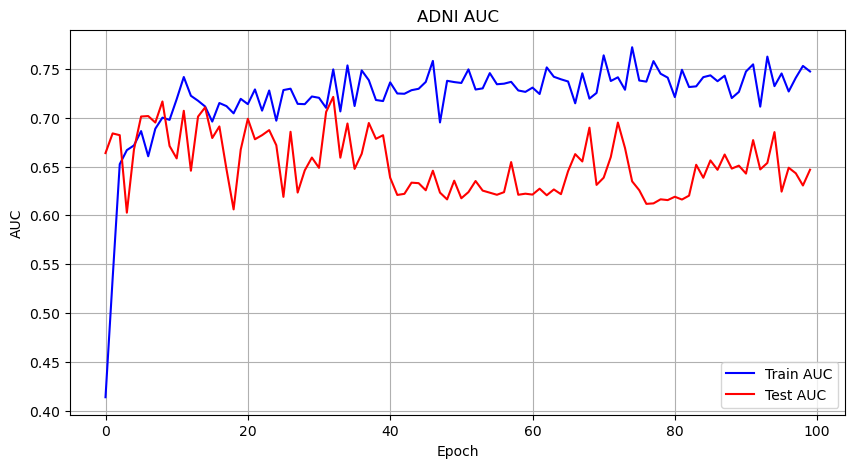

In [20]:
plt.figure(figsize=(10, 5))
plt.plot(range(len(train_aucs)), train_aucs, label="Train AUC", color="blue")
plt.plot(range(len(test_aucs)), test_aucs, label="Test AUC", color="red")
plt.title("ADNI AUC")
plt.xlabel("Epoch")
plt.ylabel("AUC")
plt.legend()
plt.grid(True)
plt.show()

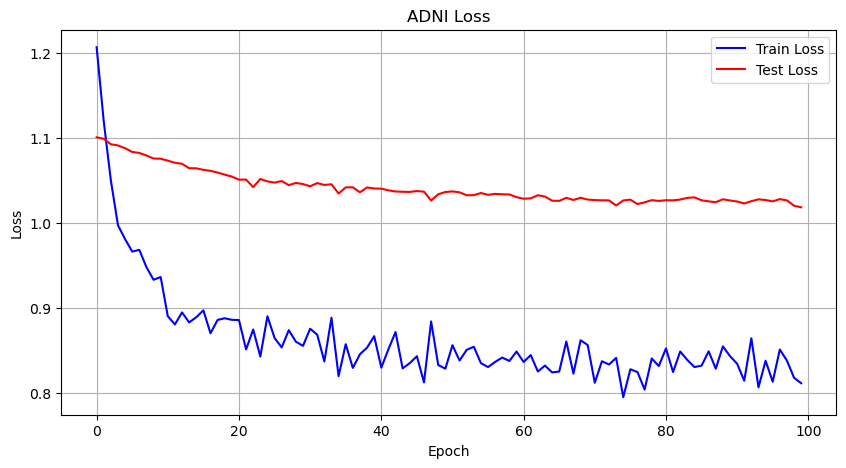

In [21]:
plt.figure(figsize=(10, 5))
plt.plot(range(len(train_losses)), train_losses, label="Train Loss", color="blue")
plt.plot(range(len(test_losses)), test_losses, label="Test Loss", color="red")
plt.title("ADNI Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()

In [22]:
def evaluate_model():
    model.eval()
    all_preds, all_probs, all_labels = [], [], []
    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs = inputs.to(device)
            outputs = model(inputs)
            probs = torch.softmax(outputs, dim=1)
            all_probs.extend(probs.cpu().numpy())
            all_preds.extend(torch.argmax(outputs, dim=1).cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
    all_probs = np.array(all_probs)
    all_preds = np.array(all_preds)
    all_labels = np.array(all_labels)
    print("\nClassification Report:")
    print(classification_report(all_labels, all_preds, target_names=['NC', 'MCI', 'AD']))
    print("Confusion Matrix:")
    print(confusion_matrix(all_labels, all_preds))
    auc = roc_auc_score(all_labels, all_probs, multi_class='ovr')  # 使用 'ovr' 或 'ovo'
    print(f"AUC Score (Ovr): {auc:.4f}")

evaluate_model()


Classification Report:
              precision    recall  f1-score   support

          NC       0.00      0.00      0.00        53
         MCI       0.57      1.00      0.72       119
          AD       0.00      0.00      0.00        38

    accuracy                           0.57       210
   macro avg       0.19      0.33      0.24       210
weighted avg       0.32      0.57      0.41       210

Confusion Matrix:
[[  0  53   0]
 [  0 119   0]
 [  0  38   0]]
AUC Score (Ovr): 0.6468


D:\Anaconda\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
D:\Anaconda\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
D:\Anaconda\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
